In [79]:
df = pd.read_parquet("0_intermediate/df.parquet")

countries = [g for g in var_groups.countries if g not in {'UK', 'ES'}]

_excl    = {'FC_OTH_NSP_E', 'FC_TRA_NSP_E', 'FC_TRA_DAVI_E', 'FC_TRA_DNAVI_E'}
subs_enw = [s for s in var_groups.subs if s not in _excl]

df = df[df.nrg_bal.isin(subs_enw) & df.geo.isin(countries)].copy()

### Energiandele

Sektor $i$'s andel af samlet energiforbrug for land $c$ i år $t$:

$$s_{i,c,t} = \frac{\text{Energi}_{i,c,t}}{\displaystyle\sum_j \text{Energi}_{j,c,t}}$$

In [80]:
def energy_shares(df_slice):
    """Energy shares and electrification rates for a country-year slice, aligned to subs_enw."""
    g = df_slice.set_index('nrg_bal')['energy_tj'].fillna(0).reindex(subs_enw, fill_value=0)
    e = df_slice.set_index('nrg_bal')['elec_share_pct'].fillna(0).reindex(subs_enw, fill_value=0)
    total = g.sum()
    s = g / total if total > 0 else g.copy()
    return s, e

total final energy consumption from all sources — electricity, gas, oil, heat, biomass, etc. — measured in TJ

### Symmetrisk shift-share dekomponering

Elektrificeringsraten $E_{c,t} = \sum_i s_{i,c,t} \cdot e_{i,c,t}$.  
Med midtvejsvægte $\bar{s}_i = \tfrac{s_{i,0}+s_{i,1}}{2}$, $\bar{e}_i = \tfrac{e_{i,0}+e_{i,1}}{2}$ gælder eksakt uden residual:

$$\Delta E = \underbrace{\sum_i \Delta s_i \cdot \bar{e}_i}_{\text{sammensætningseffekt}} + \underbrace{\sum_i \bar{s}_i \cdot \Delta e_i}_{\text{intensitetseffekt}} = E_1 - E_0$$

In [81]:
def decompose(s0, s1, e0, e1):
    """Symmetric shift-share: composition + intensity = ΔE exactly (midpoint weights, no residual)."""
    s_bar, e_bar = (s0 + s1) / 2, (e0 + e1) / 2
    ds, de = s1 - s0, e1 - e0
    return pd.Series({
        'composition': (ds * e_bar).sum(),
        'intensity':   (s_bar * de).sum(),
    })

## Analyse 1: Tidslig dekomponering (første → seneste observation, pr. land)

In [82]:
rows = []
for geo in countries:
    sub = df[df.geo == geo]
    years = sorted(sub.year.unique())
    y0, y1 = years[0], years[-1]
    s0, e0 = energy_shares(sub[sub.year == y0])
    s1, e1 = energy_shares(sub[sub.year == y1])
    res = decompose(s0, s1, e0, e1)
    res['geo'] = geo
    res['y0']  = y0
    res['y1']  = y1
    res['E0']  = (s0 * e0).sum()
    res['E1']  = (s1 * e1).sum()
    rows.append(res)

df_time = pd.DataFrame(rows).set_index('geo')
df_time['total'] = df_time[['composition', 'intensity']].sum(axis=1)
df_time[['y0', 'y1', 'E0', 'E1', 'composition', 'intensity', 'total']].round(2)

,y0,y1,E0,E1,composition,intensity,total
geo,,,,,,,
DK,1995,2023,19.10,20.47,-1.32,2.69,1.37
SE,1995,2023,32.07,35.06,-0.08,3.07,2.99
NO,1995,2023,56.88,55.54,0.70,-2.04,-1.34
DE,1995,2023,18.88,21.74,-0.20,3.06,2.86
NL,1995,2023,14.87,23.23,-0.03,8.39,8.36
FR,1995,2023,21.91,26.84,-1.52,6.45,4.93
FI,1995,2023,27.57,28.87,4.16,-2.86,1.29
EU27_2020,1995,2023,19.12,23.23,-1.42,5.53,4.11


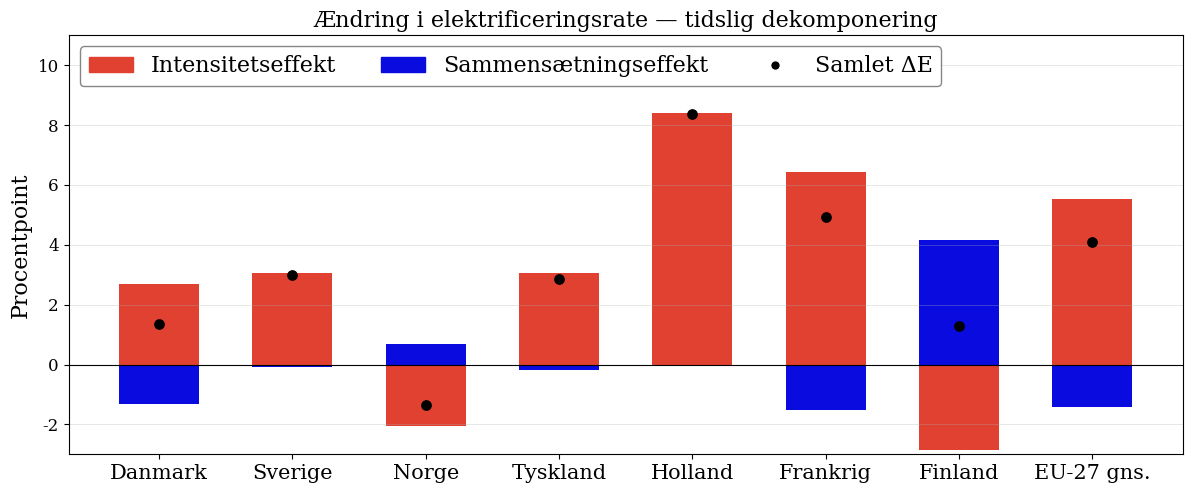

In [93]:
_COMP_COLORS = {
    'intensity':   PALETTE['DK'],
    'composition': PALETTE['FR'],
}
_COMP_LABELS = {
    'intensity':   'Intensitetseffekt',
    'composition': 'Sammensætningseffekt',
}

def stacked_decomp_bars(ax, x, df_res, components=('intensity', 'composition')):
    """Stacked bars handling mixed-sign values; returns legend patches."""
    bottom_pos = np.zeros(len(x))
    bottom_neg = np.zeros(len(x))
    patches = []
    for comp in components:
        v = df_res[comp].to_numpy()
        p = np.where(v > 0, v, 0)
        n = np.where(v < 0, v, 0)
        ax.bar(x, p, bottom=bottom_pos, color=_COMP_COLORS[comp], width=0.6)
        ax.bar(x, n, bottom=bottom_neg, color=_COMP_COLORS[comp], width=0.6)
        bottom_pos += p
        bottom_neg += n
        patches.append(Patch(color=_COMP_COLORS[comp], label=_COMP_LABELS[comp]))
    return patches


# ── Fig 1: Tidslig dekomponering ──────────────────────────────────────────────
geos = df_time.index.tolist()
x = np.arange(len(geos))

fig, ax = plt.subplots(figsize=(12, 5))

patches = stacked_decomp_bars(ax, x, df_time)
ax.scatter(x, (df_time['E1'] - df_time['E0']).to_numpy(), color='black', zorder=5, s=45,
           label='Samlet ΔE')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([var_groups.country_names[g] for g in geos], ha='center')
ax.set_ylabel('Procentpoint')
ax.set_ylim(-3,11)
ax.set_title('Ændring i elektrificeringsrate — tidslig dekomponering')
ax.grid(axis='y', linewidth=0.6, alpha=0.35)
ax.legend(handles=patches + [plt.Line2D([0],[0], marker='o', color='w',
          markerfacecolor='black', markersize=7, label='Samlet ΔE')],
          frameon=True, framealpha=0.95, edgecolor='0.5', fancybox=True,
          loc='upper left', ncols=3)
plt.tight_layout()
plt.show()

---

## Bevis: $C + I = \Delta E$

**Definitioner.**  
Lad $s_{i,t}$ være sektor $i$'s andel af samlet energiforbrug og $e_{i,t}$ dens elektrificeringsrate i periode $t \in \{0,1\}$.  
Elektrificeringsraten er den energivægtede sum

$$E_t = \sum_i s_{i,t}\, e_{i,t}.$$

Vi definerer midtvejsvægte og ændringer:

$$\bar{s}_i = \tfrac{s_{i,0}+s_{i,1}}{2}, \qquad \bar{e}_i = \tfrac{e_{i,0}+e_{i,1}}{2}, \qquad \Delta s_i = s_{i,1}-s_{i,0}, \qquad \Delta e_i = e_{i,1}-e_{i,0},$$

og dekomponeringseffekterne

$$C = \sum_i \Delta s_i\,\bar{e}_i \quad \text{(sammensætning)}, \qquad I = \sum_i \bar{s}_i\,\Delta e_i \quad \text{(intensitet)}.$$

**Påstand.** $C + I = \Delta E \equiv E_1 - E_0$.

**Bevis.**  
Beregn $C+I$ direkte fra definitionerne:

$$C + I = \sum_i \Delta s_i\,\bar{e}_i + \sum_i \bar{s}_i\,\Delta e_i = \frac{1}{2}\sum_i\bigl[(s_{i,1}-s_{i,0})(e_{i,0}+e_{i,1}) + (s_{i,0}+s_{i,1})(e_{i,1}-e_{i,0})\bigr].$$

Udvid parenteserne og bemærk at krydsled ophæver hinanden ($s_{i,1}e_{i,0}$ og $s_{i,0}e_{i,1}$ forsvinder parvist):

$$= \frac{1}{2}\sum_i\bigl[2\,s_{i,1}e_{i,1} - 2\,s_{i,0}e_{i,0}\bigr] = \sum_i s_{i,1}e_{i,1} - \sum_i s_{i,0}e_{i,0} = E_1 - E_0 = \Delta E. \qquad \blacksquare$$

**Bemærkning.**  
Beviset er en ren algebraisk identitet — den gælder for alle værdier af $s$ og $e$, uanset data. Ligestillingen $\Delta E = C + I$ er altså ikke en antagelse men en konsekvens af at vælge midtvejsvægte. Til sammenligning giver Laspeyres-dekomponeringen (fast $t_0$-reference) $C_{\text{Las}} + I_{\text{Las}} = \Delta E - \sum_i \Delta s_i \Delta e_i$, og det resterende interaktionsled er et indekstalsproblem uden substantiel fortolkning.